# Import

In [187]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import torch

# Configure device

In [188]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU")

def reset_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

Using device: cuda
GPU: NVIDIA GeForce MX570 A


# Load Shared Sequence

In [189]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent.parent
SHARED_DIR = PROJECT_ROOT / "data" / "shared"

# Load shared vocabulary
with open(SHARED_DIR / "vocabulary.pkl", "rb") as file:
    vocabulary_data = pickle.load(file)

# vocabulary_data is a dict
# vocabulary_data = {
#   "word_to_idx": word_to_idx,
#   "MAX_LENGTH":max_length
# }

word_to_idx = vocabulary_data["word_to_idx"]
MAX_LENGTH = vocabulary_data["MAX_LENGTH"]

# Load shared sequences, lengths, labels, and text splits
shared_data = np.load(
    SHARED_DIR / "sequence_data.npz",
    allow_pickle=True
)
# np.load() does not allow python objects to be loaded because of security reasons
# pickle is Python's way of saving python objects to a file and then reconstructing them later
# pickle=True => If this file contains pickled Python objects, it's okay to reconstruct them

train_padded = shared_data["train_padded"]
val_padded = shared_data["val_padded"]
test_padded = shared_data["test_padded"]

train_lengths = shared_data["train_lengths"]
val_lengths = shared_data["val_lengths"]
test_lengths = shared_data["test_lengths"]

y_train = shared_data["y_train"]
y_val = shared_data["y_val"]
y_test = shared_data["y_test"]

# Recreate the DataFrames needed by TF-IDF and Word2Vec
train_data = pd.DataFrame({
    "processed_text": shared_data["train_texts"],
    "label": y_train
})

val_data = pd.DataFrame({
    "processed_text": shared_data["val_texts"],
    "label": y_val
})

test_df = pd.DataFrame({
    "processed_text": shared_data["test_texts"],
    "label": y_test
})

# Recreate token lists needed by Word2Vec
train_tokens = train_data["processed_text"].str.split()
val_tokens = val_data["processed_text"].str.split()
test_tokens = test_df["processed_text"].str.split()

print("Shared data loaded successfully.")
print("Vocabulary size:", len(word_to_idx))
print("Maximum sequence length:", MAX_LENGTH)
print("Training shape:", train_padded.shape)
print("Validation shape:", val_padded.shape)
print("Testing shape:", test_padded.shape)

Shared data loaded successfully.
Vocabulary size: 60725
Maximum sequence length: 321
Training shape: (19923, 321)
Validation shape: (4981, 321)
Testing shape: (24801, 321)


# Word2Vec

In [190]:
# import time
# import gensim.downloader as api

# start_time = time.time()

# print("Loading pretrained Google News Word2Vec...")
# word2vec_model = api.load("word2vec-google-news-300")

# elapsed_time = time.time() - start_time

# print("Word2Vec loaded successfully.")
# print(f"Vector size: {word2vec_model.vector_size}")
# print(f"Loading time: {elapsed_time / 60:.2f} minutes")


## training on IMDB

In [191]:
from gensim.models import Word2Vec
# importing the Word2Vec implementation from Gensim
import time

start_time = time.time()

word2vec_model = Word2Vec(
    sentences=train_tokens.tolist(),
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10,
    seed=SEED
)

elapsed_time = time.time() - start_time

print("Word2Vec training completed.")
print("Vector size:", word2vec_model.vector_size)
print("Vocabulary size:", len(word2vec_model.wv))
# the vocabulary trained after removing the words with occ<min_count
print(f"Training time: {elapsed_time / 60:.2f} minutes")

Word2Vec training completed.
Vector size: 100
Vocabulary size: 37953
Training time: 1.02 minutes


In [192]:
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

## save the trained model


In [193]:
WORD2VEC_PATH = MODELS_DIR / "word2vec_imdb.model"
word2vec_model.save(str(WORD2VEC_PATH))
print("Word2Vec model saved to:", WORD2VEC_PATH)

Word2Vec model saved to: models\word2vec_imdb.model


In [194]:
# save the word2vec model in the shared folder
SHARED_MODELS_DIR=SHARED_DIR/"models"
SHARED_MODELS_DIR.mkdir(parents=True, exist_ok=True)
SHARED_PATH = SHARED_MODELS_DIR/ "word2vec_imdb.model"
word2vec_model.save(str(SHARED_PATH))
print("Word2Vec model saved to:", SHARED_PATH)

Word2Vec model saved to: c:\Users\User\Desktop\inmind\assignments\code\assignment4_NLP_SequenceModels\data\shared\models\word2vec_imdb.model


## build word2Vec embedding matrix

In [195]:
word2vec_vectors = word2vec_model.wv #word vectors: contains all the learned embeddings
WORD2VEC_DIM = word2vec_vectors.vector_size
# = 100

rng = np.random.default_rng(SEED) #random generator

word2vec_embedding_matrix = rng.normal(
    loc=0.0,
    scale=0.05,
    size=(len(word_to_idx), WORD2VEC_DIM)
).astype(np.float32)
# each word has a random vector

# Padding must stay zero because it has no information
word2vec_embedding_matrix[word_to_idx["<PAD>"]] = 0.0

matched_words = 0

for word, idx in word_to_idx.items():
    if word in word2vec_vectors:
        word2vec_embedding_matrix[idx] = word2vec_vectors[word] #replace the random vector with the learned vector
        matched_words += 1

word2vec_coverage = matched_words / len(word_to_idx) * 100
# compute the percentage of vocabulary coverage

print("Word2Vec matrix shape:", word2vec_embedding_matrix.shape)
print("Matched words:", matched_words)
print(f"Vocabulary coverage: {word2vec_coverage:.2f}%")

Word2Vec matrix shape: (60725, 100)
Matched words: 37953
Vocabulary coverage: 62.50%


## save the matrix

In [196]:
np.save(
    MODELS_DIR / "word2vec_embedding_matrix.npy",
    word2vec_embedding_matrix
)

print("Word2Vec embedding matrix saved.")

Word2Vec embedding matrix saved.


# GloVe

## load the pretrained glove model

In [197]:
import time
import gensim.downloader as api

start_time = time.time()

print("Loading pretrained GloVe...")
glove_model = api.load("glove-wiki-gigaword-100")

elapsed_time = time.time() - start_time

print("GloVe loaded successfully.")
print("Vector size:", glove_model.vector_size)
print(f"Loading time: {elapsed_time / 60:.2f} minutes")

Loading pretrained GloVe...
GloVe loaded successfully.
Vector size: 100
Loading time: 1.76 minutes


## create the glove embedded matrix

In [198]:
GLOVE_DIM = glove_model.vector_size

rng = np.random.default_rng(SEED)

glove_embedding_matrix = rng.normal(
    loc=0.0,
    scale=0.05,
    size=(len(word_to_idx), GLOVE_DIM)
).astype(np.float32)

glove_embedding_matrix[word_to_idx["<PAD>"]] = 0.0

matched_words = 0

for word, idx in word_to_idx.items():
    if word in glove_model:
        glove_embedding_matrix[idx] = glove_model[word]
        matched_words += 1

glove_coverage = matched_words / len(word_to_idx) * 100

print("GloVe matrix shape:", glove_embedding_matrix.shape)
print("Matched words:", matched_words)
print(f"Vocabulary coverage: {glove_coverage:.2f}%")

GloVe matrix shape: (60725, 100)
Matched words: 49464
Vocabulary coverage: 81.46%


## save the embedding matrix

In [199]:
np.save(
    MODELS_DIR / "glove_embedding_matrix.npy",
    glove_embedding_matrix
)

print("GloVe embedding matrix saved.")

GloVe embedding matrix saved.


# TF-IDF

## Vectorization

In [200]:
from sklearn.feature_extraction.text import TfidfVectorizer

MAX_FEATURES = 20000

tfidf_vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES
)

X_train_tfidf = tfidf_vectorizer.fit_transform(
    train_data["processed_text"]
)

X_val_tfidf = tfidf_vectorizer.transform(
    val_data["processed_text"]
)

X_test_tfidf = tfidf_vectorizer.transform(
    test_df["processed_text"]
)

print("Train:", X_train_tfidf.shape)
print("Validation:", X_val_tfidf.shape)
print("Test:", X_test_tfidf.shape)
print("Vocabulary size:", len(tfidf_vectorizer.vocabulary_))

Train: (19923, 20000)
Validation: (4981, 20000)
Test: (24801, 20000)
Vocabulary size: 20000


## save tf-idf vector and data to the shared folder

In [201]:
import pickle
from scipy.sparse import save_npz

SHARED_TFIDF_DIR = SHARED_DIR / "tfidf"
SHARED_TFIDF_DIR.mkdir(parents=True, exist_ok=True)


with open(
    SHARED_TFIDF_DIR / "tfidf_vectorizer.pkl",
    "wb"
) as file:
    pickle.dump(tfidf_vectorizer, file)


save_npz(
    SHARED_TFIDF_DIR / "X_train_tfidf.npz",
    X_train_tfidf
)

save_npz(
    SHARED_TFIDF_DIR / "X_val_tfidf.npz",
    X_val_tfidf
)

save_npz(
    SHARED_TFIDF_DIR / "X_test_tfidf.npz",
    X_test_tfidf
)

print("Shared TF-IDF files saved successfully.")
print("Location:", SHARED_TFIDF_DIR)

Shared TF-IDF files saved successfully.
Location: c:\Users\User\Desktop\inmind\assignments\code\assignment4_NLP_SequenceModels\data\shared\tfidf


## Dataset and dataloaders

In [202]:
from torch.utils.data import Dataset, DataLoader


class TfidfDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features #stores sparse matrix
        self.labels = np.asarray(labels, dtype=np.float32) #stores labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        # Convert only the requested sparse row to a dense tensor
        feature = self.features[index].toarray().squeeze() #converts sparse matrix to array and then removes unnecessary dimensions
        # original sparse matrix: example: index 1 -> 3, index 4 ->2
        # numpy array: [0,3,0,0,2]
        # squeeze only removes the dimensions of 1

        return (
            torch.tensor(feature, dtype=torch.float32),
            torch.tensor(self.labels[index], dtype=torch.float32)
        )

In [203]:
tfidf_train_dataset = TfidfDataset(
    X_train_tfidf,
    y_train
)

tfidf_val_dataset = TfidfDataset(
    X_val_tfidf,
    y_val
)

tfidf_test_dataset = TfidfDataset(
    X_test_tfidf,
    y_test
)

In [204]:
TFIDF_BATCH_SIZE = 32
# every iteration, receive 32 reviews only

tfidf_train_loader = DataLoader(
    tfidf_train_dataset,
    batch_size=TFIDF_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=device.type == "cuda"
)

tfidf_val_loader = DataLoader(
    tfidf_val_dataset,
    batch_size=TFIDF_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=device.type == "cuda"
)

tfidf_test_loader = DataLoader(
    tfidf_test_dataset,
    batch_size=TFIDF_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=device.type == "cuda"
)
# only shuffle the training set, no need to shuffle the test and validation
# pin memory to reserve RAM memory to make transfer faster


In [205]:
# check one batch
features_batch, labels_batch = next(iter(tfidf_train_loader))

print("Features shape:", features_batch.shape)
print("Labels shape:", labels_batch.shape)

Features shape: torch.Size([32, 20000])
Labels shape: torch.Size([32])


# Pytorch dataset and data loaders

In [206]:
from torch.utils.data import Dataset, DataLoader
class ReviewDataset(Dataset):
    def __init__(self, sequences, lengths, labels):
        self.sequences = torch.tensor(
            sequences,
            dtype=torch.long #long because they are indices to the vectors in the embedding matrix
        )

        self.lengths = torch.tensor(
            lengths,
            dtype=torch.long
        )

        self.labels = torch.tensor(
            labels,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return (
            self.sequences[index],
            self.lengths[index],
            self.labels[index]
        )

## create the datasets

In [207]:
train_dataset = ReviewDataset(
    train_padded,
    train_lengths,
    y_train
)

val_dataset = ReviewDataset(
    val_padded,
    val_lengths,
    y_val
)

test_dataset = ReviewDataset(
    test_padded,
    test_lengths,
    y_test
)

## create the data loaders

In [208]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=device.type == "cuda"
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=device.type == "cuda"
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=device.type == "cuda"
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

Training batches: 623
Validation batches: 156
Testing batches: 776


## check one batch

In [209]:
sequences_batch, lengths_batch, labels_batch = next(
    iter(train_loader)
)

print("Sequences shape:", sequences_batch.shape)
print("Lengths shape:", lengths_batch.shape)
print("Labels shape:", labels_batch.shape)

Sequences shape: torch.Size([32, 321])
Lengths shape: torch.Size([32])
Labels shape: torch.Size([32])


# LSTM Model

In [210]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence
class LSTMClassifier(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        hidden_size=128,
        num_layers=1,
        dropout=0.3,
        freeze_embeddings=True
    ):
        super().__init__()

        # convert the embedding matrix into a tensor because Pytorch layers need tensors not numpy arrays
        embedding_tensor = torch.tensor(
            embedding_matrix,
            dtype=torch.float32
        )
        # The LSTM compresses the important information from the review into a 128-dimensional summary
        
        # create the embedding layer -> create a lookup table using the matrix
        # example: if input sequence is [5,7,3,2]
        # this retrieves the rows 5,7,3,2 from the embedding matrix
        self.embedding = nn.Embedding.from_pretrained(
            embedding_tensor,
            freeze=freeze_embeddings, 
            padding_idx=word_to_idx["<PAD>"]
        )
        # if freeze_embeddings = True, the embedding vectors stay unchanged during the training process otherwise, LSTM can change them through backpropagation
        # padding_idx is needed to avoid updating the zeros
        # embedding_matrix.shape: [32,321,100]

        embedding_dim = embedding_matrix.shape[1] #nb of values representing each word

        # create the LSTM layer
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout) #dropout to the final hidden representation before classification    
        # dropout helps reduce overfitting (sets values to 0)
        self.output = nn.Linear(hidden_size, 1)
        # convert to 1 number

    # what happens when the batch enters the model
    def forward(self, sequences, lengths):
        embedded = self.embedding(sequences) #each ID is replaced with its 100-dimensional embedding vector
        # [32,321,100]

        # this ignores the padding
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, (hidden, _) = self.lstm(packed) #this contains the final hidden state
        # [32,128]

        final_hidden = hidden[-1] #one 128 value representation for each review [32,128]
        final_hidden = self.dropout(final_hidden)

        # linear layer: convert the 128 values into 1 number called logit
        logits = self.output(final_hidden).squeeze(1)
        # [32] => 1 value for each review
        

        return logits

## TF-IDF LSTM Model

In [211]:
class TfidfLSTMClassifier(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=128,
        num_layers=1,
        dropout=0.3
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, features):
        # [batch, features] -> [batch, 1, features] because LSTM expects a sequence
        features = features.unsqueeze(1)

        _, (hidden_state, _) = self.lstm(features)

        final_hidden = hidden_state[-1]
        final_hidden = self.dropout(final_hidden)

        logits = self.fc(final_hidden).squeeze(1)

        return logits

# Training functions

## Word2Vec and GloVe

In [212]:
def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device
):
    model.train() #inherited from nn.Module
    # dropout ON
    # gradients computed

    # accumulate statistics over the whole epoch (all the batches)
    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # dataloader provides one batch at a time
    # move everything to the selected device (gpu)
    for sequences, lengths, labels in data_loader:
        sequences = sequences.to(device, non_blocking=True) #(32,321)
        lengths = lengths.to(device, non_blocking=True) #(32)
        labels = labels.to(device, non_blocking=True) #(32)

        optimizer.zero_grad() #clear gradients because pytorch accumulates gradients

        logits = model(sequences, lengths) #run the review through the entire network (till obtaining the logits)
        loss = criterion(logits, labels) #criterion = BCEWithLogitsLoss()
        # compares predictions and true labels

        loss.backward() #compute the gradients

        # Helps reduce exploding gradients
        # gradients might become very lage => limit them to 1
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step() #optimizer updates all the weights

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        total_loss += loss.item() * labels.size(0) #total loss = avg loss of one batch * nb of reviews

        correct_predictions += (
            predictions == labels
        ).sum().item()

        total_samples += labels.size(0) #count how many reviews have been processed

    average_loss = total_loss / total_samples
    accuracy = correct_predictions / total_samples

    return average_loss, accuracy

In [213]:
def validate_one_epoch(
    model,
    data_loader,
    criterion,
    device
):
    model.eval() #dropout off

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad(): #dont compute or store gradients
        for sequences, lengths, labels in data_loader:
            sequences = sequences.to(device, non_blocking=True)
            lengths = lengths.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(sequences, lengths)
            loss = criterion(logits, labels)

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).float()

            total_loss += loss.item() * labels.size(0)
            correct_predictions += (
                predictions == labels
            ).sum().item()

            total_samples += labels.size(0)

    average_loss = total_loss / total_samples
    accuracy = correct_predictions / total_samples

    return average_loss, accuracy

## TF-IDF

In [214]:
def train_tfidf_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device
):
    model.train()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for features, labels in data_loader:
        features = features.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(features)
        loss = criterion(logits, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        total_loss += loss.item() * labels.size(0)
        correct_predictions += (
            predictions == labels
        ).sum().item()

        total_samples += labels.size(0)

    average_loss = total_loss / total_samples
    accuracy = correct_predictions / total_samples

    return average_loss, accuracy

In [215]:
def validate_tfidf_one_epoch(
    model,
    data_loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(features)
            loss = criterion(logits, labels)

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).float()

            total_loss += loss.item() * labels.size(0)
            correct_predictions += (
                predictions == labels
            ).sum().item()

            total_samples += labels.size(0)

    average_loss = total_loss / total_samples
    accuracy = correct_predictions / total_samples

    return average_loss, accuracy

## complete training function

In [216]:
import copy
import time
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    model_path
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    best_val_loss = float("inf")
    best_model_state = None

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_accuracy = validate_one_epoch(
            model,
            val_loader,
            criterion,
            device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Accuracy: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Accuracy: {val_accuracy:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            torch.save(
                best_model_state,
                model_path
            )

            print("Best model saved.")

    elapsed_time = time.time() - start_time

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(
        f"\nTraining completed in "
        f"{elapsed_time / 60:.2f} minutes."
    )

    return history

### TF-IDF training fct

In [217]:
def train_tfidf_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    model_path
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    best_val_loss = float("inf")
    best_model_state = None

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = train_tfidf_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_accuracy = validate_tfidf_one_epoch(
            model,
            val_loader,
            criterion,
            device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Accuracy: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Accuracy: {val_accuracy:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())

            torch.save(best_model_state, model_path)
            print("Best model saved.")

    elapsed_time = time.time() - start_time

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(
        f"\nTraining completed in "
        f"{elapsed_time / 60:.2f} minutes."
    )

    return history

# Evaluation functions

In [218]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
def evaluate_model(model, data_loader, device):
    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for sequences, lengths, labels in data_loader:
            sequences = sequences.to(device, non_blocking=True)
            lengths = lengths.to(device, non_blocking=True)

            logits = model(sequences, lengths)

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).long()

            all_labels.extend(
                labels.numpy().astype(int)
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    metrics = {
        "accuracy": accuracy_score(
            all_labels,
            all_predictions
        ),
        "precision": precision_score(
            all_labels,
            all_predictions,
            zero_division=0
        ),
        "recall": recall_score(
            all_labels,
            all_predictions,
            zero_division=0
        ),
        "f1": f1_score(
            all_labels,
            all_predictions,
            zero_division=0
        )
    }

    return (
        metrics,
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities)
    )

## TF-IDF evaluation fct

In [219]:
def evaluate_tfidf_model(model, data_loader, device):
    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(
                device,
                non_blocking=True
            )

            logits = model(features)

            probabilities = torch.sigmoid(logits)
            predictions = (
                probabilities >= 0.5
            ).long()

            all_labels.extend(
                labels.numpy().astype(int)
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    metrics = {
        "accuracy": accuracy_score(
            all_labels,
            all_predictions
        ),
        "precision": precision_score(
            all_labels,
            all_predictions,
            zero_division=0
        ),
        "recall": recall_score(
            all_labels,
            all_predictions,
            zero_division=0
        ),
        "f1": f1_score(
            all_labels,
            all_predictions,
            zero_division=0
        )
    }

    return (
        metrics,
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities)
    )

## plot training curves

In [220]:
import matplotlib.pyplot as plt
def plot_training_history(history, title):
    plt.figure(figsize=(8, 5))

    plt.plot(
        history["train_loss"],
        label="Training Loss"
    )

    plt.plot(
        history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))

    plt.plot(
        history["train_accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.show()

# Experiments

## Settings


In [221]:
HIDDEN_SIZE = 128
NUM_LAYERS = 1
DROPOUT = 0.3
LEARNING_RATE = 0.001
EPOCHS = 5

In [222]:
# Small LSTM hyperparameter search using validation loss
# Word2Vec Frozen is used so that tuning remains quick.
import gc

TUNING_CONFIGS = [
    {
        "hidden_size": 64,
        "num_layers": 1,
        "dropout": 0.3,
        "learning_rate": 0.001
    },
    {
        "hidden_size": 128,
        "num_layers": 1,
        "dropout": 0.3,
        "learning_rate": 0.001
    },
    {
        "hidden_size": 128,
        "num_layers": 2,
        "dropout": 0.3,
        "learning_rate": 0.001
    }
]


TUNING_EPOCHS = 5

tuning_dir = MODELS_DIR / "lstm_tuning"
tuning_dir.mkdir(parents=True, exist_ok=True)

tuning_results = []

for config_number, config in enumerate(TUNING_CONFIGS, start=1):

    # Reset seeds so that configurations are compared consistently.
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    print("\n" + "=" * 60)
    print(f"Configuration {config_number}: {config}")
    print("=" * 60)

    tuning_model = LSTMClassifier(
        embedding_matrix=word2vec_embedding_matrix,
        hidden_size=config["hidden_size"],
        num_layers=config["num_layers"],
        dropout=config["dropout"],
        freeze_embeddings=True
    ).to(device)

    tuning_criterion = nn.BCEWithLogitsLoss()

    tuning_optimizer = torch.optim.Adam(
        filter(
            lambda parameter: parameter.requires_grad,
            tuning_model.parameters()
        ),
        lr=config["learning_rate"]
    )

    tuning_history = train_model(
        model=tuning_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=tuning_criterion,
        optimizer=tuning_optimizer,
        device=device,
        epochs=TUNING_EPOCHS,
        model_path=(
            tuning_dir /
            f"lstm_config_{config_number}.pt"
        )
    )

    best_val_loss = min(tuning_history["val_loss"])
    best_epoch = tuning_history["val_loss"].index(best_val_loss) + 1

    tuning_results.append({
        **config,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss
    })

    del tuning_model, tuning_optimizer
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


tuning_results_df = pd.DataFrame(tuning_results)
tuning_results_df = tuning_results_df.sort_values(
    "best_val_loss"
).reset_index(drop=True)

display(tuning_results_df)

best_config = tuning_results_df.iloc[0]

print("\nSelected LSTM configuration:")
print(best_config)


Configuration 1: {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.3, 'learning_rate': 0.001}


Epoch 01/5 | Train Loss: 0.4419 | Train Accuracy: 0.8008 | Val Loss: 0.4420 | Val Accuracy: 0.8153
Best model saved.
Epoch 02/5 | Train Loss: 0.3619 | Train Accuracy: 0.8564 | Val Loss: 0.3161 | Val Accuracy: 0.8679
Best model saved.
Epoch 03/5 | Train Loss: 0.3388 | Train Accuracy: 0.8637 | Val Loss: 0.3335 | Val Accuracy: 0.8677
Epoch 04/5 | Train Loss: 0.3034 | Train Accuracy: 0.8764 | Val Loss: 0.2887 | Val Accuracy: 0.8795
Best model saved.
Epoch 05/5 | Train Loss: 0.2868 | Train Accuracy: 0.8857 | Val Loss: 0.2811 | Val Accuracy: 0.8876
Best model saved.

Training completed in 1.74 minutes.

Configuration 2: {'hidden_size': 128, 'num_layers': 1, 'dropout': 0.3, 'learning_rate': 0.001}
Epoch 01/5 | Train Loss: 0.4154 | Train Accuracy: 0.8210 | Val Loss: 0.3302 | Val Accuracy: 0.8701
Best model saved.
Epoch 02/5 | Train Loss: 0.3679 | Train Accuracy: 0.8489 | Val Loss: 0.3409 | Val Accuracy: 0.8611
Epoch 03/5 | Train Loss: 0.3326 | Train Accuracy: 0.8636 | Val Loss: 0.3025 | Val Ac

,hidden_size,num_layers,dropout,learning_rate,best_epoch,best_val_loss
0,128,2,0.3,0.001,5,0.264091
1,128,1,0.3,0.001,5,0.275672
2,64,1,0.3,0.001,5,0.281134



Selected LSTM configuration:
hidden_size      128.000000
num_layers         2.000000
dropout            0.300000
learning_rate      0.001000
best_epoch         5.000000
best_val_loss      0.264091
Name: 0, dtype: float64


In [223]:
HIDDEN_SIZE = int(best_config["hidden_size"])
NUM_LAYERS = int(best_config["num_layers"])
DROPOUT = float(best_config["dropout"])
LEARNING_RATE = float(best_config["learning_rate"])

# Keep five epochs for the real final training.
EPOCHS = 5

print("Final LSTM parameters:")
print("Hidden size:", HIDDEN_SIZE)
print("Number of layers:", NUM_LAYERS)
print("Dropout:", DROPOUT)
print("Learning rate:", LEARNING_RATE)
print("Epochs:", EPOCHS)

Final LSTM parameters:
Hidden size: 128
Number of layers: 2
Dropout: 0.3
Learning rate: 0.001
Epochs: 5


## TF-IDF

In [224]:
reset_seed()
TFIDF_INPUT_SIZE = X_train_tfidf.shape[1]

tfidf_model = TfidfLSTMClassifier(
    input_size=TFIDF_INPUT_SIZE,
    hidden_size=128,
    num_layers=1,
    dropout=0.3
).to(device)

tfidf_criterion = nn.BCEWithLogitsLoss()

tfidf_optimizer = torch.optim.Adam(
    tfidf_model.parameters(),
    lr=LEARNING_RATE
)

TFIDF_MODEL_PATH = MODELS_DIR / "lstm_tfidf.pt"

In [225]:
print("Training TF-IDF LSTM...")
print(f"Device: {device}")

tfidf_history = train_tfidf_model(
    model=tfidf_model,
    train_loader=tfidf_train_loader,
    val_loader=tfidf_val_loader,
    criterion=tfidf_criterion,
    optimizer=tfidf_optimizer,
    device=device,
    epochs=EPOCHS,
    model_path=TFIDF_MODEL_PATH
)

Training TF-IDF LSTM...
Device: cuda
Epoch 01/5 | Train Loss: 0.3922 | Train Accuracy: 0.8513 | Val Loss: 0.2517 | Val Accuracy: 0.8962
Best model saved.
Epoch 02/5 | Train Loss: 0.1594 | Train Accuracy: 0.9444 | Val Loss: 0.2659 | Val Accuracy: 0.8918
Epoch 03/5 | Train Loss: 0.0896 | Train Accuracy: 0.9724 | Val Loss: 0.3106 | Val Accuracy: 0.8840
Epoch 04/5 | Train Loss: 0.0467 | Train Accuracy: 0.9881 | Val Loss: 0.3792 | Val Accuracy: 0.8765
Epoch 05/5 | Train Loss: 0.0227 | Train Accuracy: 0.9959 | Val Loss: 0.4477 | Val Accuracy: 0.8757

Training completed in 1.39 minutes.


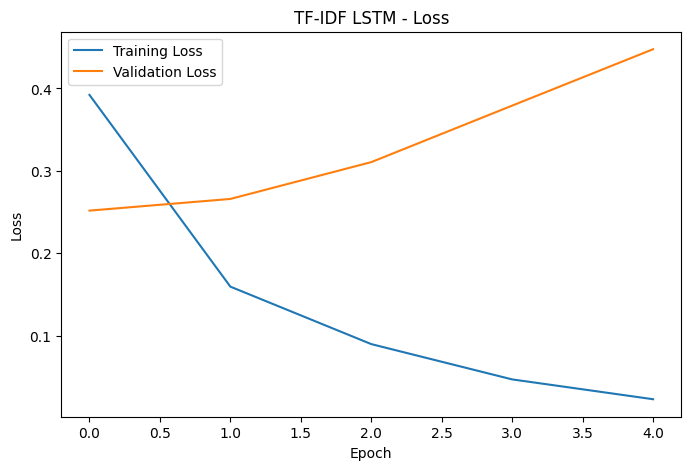

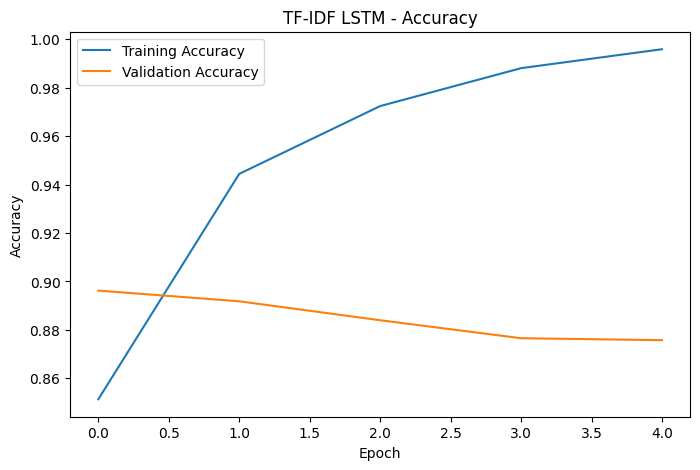

In [226]:
plot_training_history(
    tfidf_history,
    "TF-IDF LSTM"
)

In [227]:
(
    tfidf_metrics,
    tfidf_labels,
    tfidf_predictions,
    tfidf_probabilities
) = evaluate_tfidf_model(
    tfidf_model,
    tfidf_test_loader,
    device
)

print(tfidf_metrics)

{'accuracy': 0.8816983186161849, 'precision': 0.900084175084175, 'recall': 0.8595659163987138, 'f1': 0.8793585526315789}


In [228]:
print(
    classification_report(
        tfidf_labels,
        tfidf_predictions,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.86      0.90      0.88     12361
    Positive       0.90      0.86      0.88     12440

    accuracy                           0.88     24801
   macro avg       0.88      0.88      0.88     24801
weighted avg       0.88      0.88      0.88     24801



In [229]:
tfidf_confusion_matrix = confusion_matrix(
    tfidf_labels,
    tfidf_predictions
)

print(tfidf_confusion_matrix)

[[11174  1187]
 [ 1747 10693]]


## Frozen GloVe LSTM

In [230]:
reset_seed()
glove_frozen_model = LSTMClassifier(
    embedding_matrix=glove_embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    freeze_embeddings=True
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    filter(
        lambda parameter: parameter.requires_grad,
        glove_frozen_model.parameters()
    ),
    lr=LEARNING_RATE
)

print("Training Frozen GloVe LSTM...")
print("Device:", device)

glove_frozen_history = train_model(
    model=glove_frozen_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_path=MODELS_DIR / "lstm_glove_frozen.pt"
)

Training Frozen GloVe LSTM...
Device: cuda
Epoch 01/5 | Train Loss: 0.5393 | Train Accuracy: 0.7404 | Val Loss: 0.4576 | Val Accuracy: 0.7968
Best model saved.
Epoch 02/5 | Train Loss: 0.4166 | Train Accuracy: 0.8194 | Val Loss: 0.3699 | Val Accuracy: 0.8452
Best model saved.
Epoch 03/5 | Train Loss: 0.3535 | Train Accuracy: 0.8527 | Val Loss: 0.3752 | Val Accuracy: 0.8302
Epoch 04/5 | Train Loss: 0.3246 | Train Accuracy: 0.8667 | Val Loss: 0.3829 | Val Accuracy: 0.8456
Epoch 05/5 | Train Loss: 0.2959 | Train Accuracy: 0.8808 | Val Loss: 0.3155 | Val Accuracy: 0.8757
Best model saved.

Training completed in 6.31 minutes.


In [231]:
(
    glove_frozen_metrics,
    glove_frozen_labels,
    glove_frozen_predictions,
    glove_frozen_probabilities
) = evaluate_model(
    glove_frozen_model,
    test_loader,
    device
)

print(glove_frozen_metrics)

print(
    classification_report(
        glove_frozen_labels,
        glove_frozen_predictions,
        target_names=["Negative", "Positive"]
    )
)

print(
    confusion_matrix(
        glove_frozen_labels,
        glove_frozen_predictions
    )
)

{'accuracy': 0.8756098544413532, 'precision': 0.8961632929618023, 'recall': 0.8505627009646303, 'f1': 0.8727677650843403}
              precision    recall  f1-score   support

    Negative       0.86      0.90      0.88     12361
    Positive       0.90      0.85      0.87     12440

    accuracy                           0.88     24801
   macro avg       0.88      0.88      0.88     24801
weighted avg       0.88      0.88      0.88     24801

[[11135  1226]
 [ 1859 10581]]


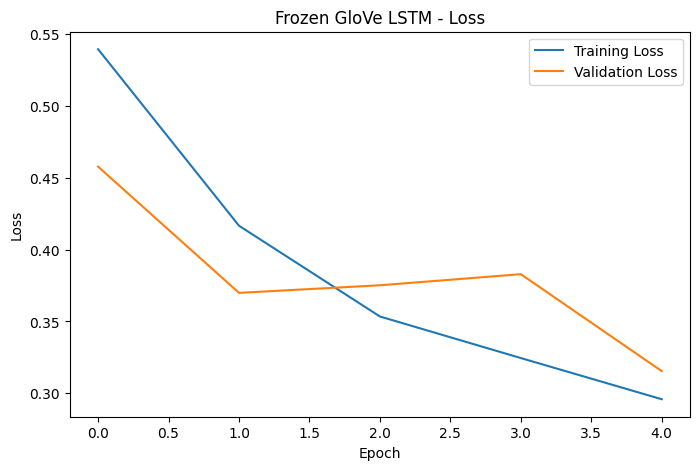

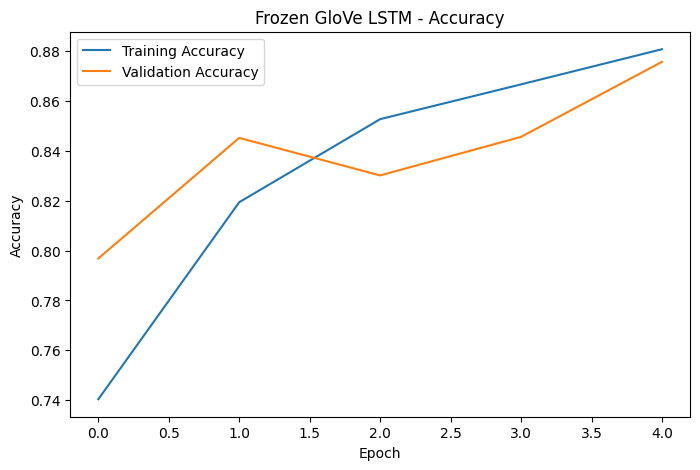

In [232]:
plot_training_history(
    glove_frozen_history,
    "Frozen GloVe LSTM"
)

In [233]:
import gc

del optimizer
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Fine tuned GloVe LSTM 

In [234]:
reset_seed()
glove_finetuned_model = LSTMClassifier(
    embedding_matrix=glove_embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    freeze_embeddings=False
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    glove_finetuned_model.parameters(),
    lr=LEARNING_RATE
)

print("Training Fine-Tuned GloVe LSTM...")
print("Device:", device)

glove_finetuned_history = train_model(
    model=glove_finetuned_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_path=MODELS_DIR / "lstm_glove_finetuned.pt"
)

Training Fine-Tuned GloVe LSTM...
Device: cuda
Epoch 01/5 | Train Loss: 0.4822 | Train Accuracy: 0.7807 | Val Loss: 0.3629 | Val Accuracy: 0.8571
Best model saved.
Epoch 02/5 | Train Loss: 0.2736 | Train Accuracy: 0.8963 | Val Loss: 0.3060 | Val Accuracy: 0.8717
Best model saved.
Epoch 03/5 | Train Loss: 0.1455 | Train Accuracy: 0.9527 | Val Loss: 0.3107 | Val Accuracy: 0.8826
Epoch 04/5 | Train Loss: 0.0648 | Train Accuracy: 0.9818 | Val Loss: 0.4824 | Val Accuracy: 0.8681
Epoch 05/5 | Train Loss: 0.0242 | Train Accuracy: 0.9939 | Val Loss: 0.5724 | Val Accuracy: 0.8693

Training completed in 10.97 minutes.


In [235]:
(
    glove_finetuned_metrics,
    glove_finetuned_labels,
    glove_finetuned_predictions,
    glove_finetuned_probabilities
) = evaluate_model(
    glove_finetuned_model,
    test_loader,
    device
)

print(glove_finetuned_metrics)

print(
    classification_report(
        glove_finetuned_labels,
        glove_finetuned_predictions,
        target_names=["Negative", "Positive"]
    )
)

print(
    confusion_matrix(
        glove_finetuned_labels,
        glove_finetuned_predictions
    )
)

{'accuracy': 0.8660537881537035, 'precision': 0.8396156138259833, 'recall': 0.9060289389067524, 'f1': 0.8715589236003711}
              precision    recall  f1-score   support

    Negative       0.90      0.83      0.86     12361
    Positive       0.84      0.91      0.87     12440

    accuracy                           0.87     24801
   macro avg       0.87      0.87      0.87     24801
weighted avg       0.87      0.87      0.87     24801

[[10208  2153]
 [ 1169 11271]]


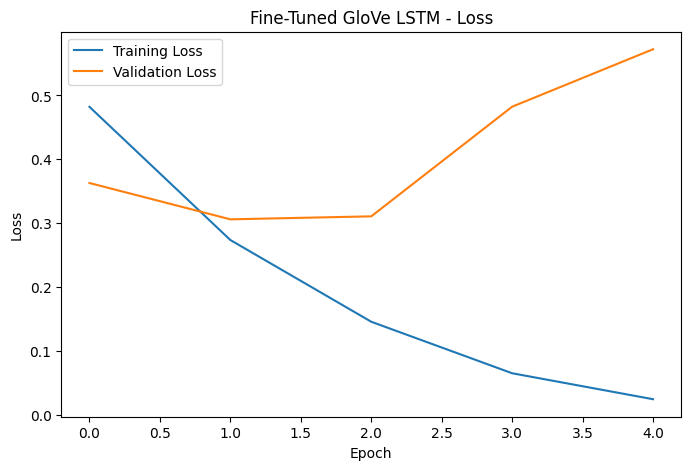

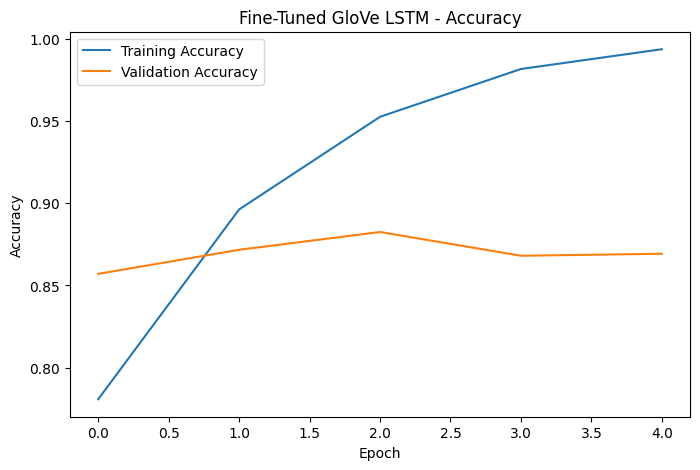

In [236]:
plot_training_history(
    glove_finetuned_history,
    "Fine-Tuned GloVe LSTM"
)

In [237]:
del optimizer
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Frozen word2Vec LSTM

In [238]:
reset_seed()
word2vec_frozen_model = LSTMClassifier(
    embedding_matrix=word2vec_embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    freeze_embeddings=True
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    filter(
        lambda parameter: parameter.requires_grad,
        word2vec_frozen_model.parameters()
    ),
    lr=LEARNING_RATE
)

print("Training Frozen Word2Vec LSTM...")
print("Device:", device)

word2vec_frozen_history = train_model(
    model=word2vec_frozen_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_path=MODELS_DIR / "lstm_word2vec_frozen.pt"
)

Training Frozen Word2Vec LSTM...
Device: cuda
Epoch 01/5 | Train Loss: 0.5341 | Train Accuracy: 0.7329 | Val Loss: 0.3723 | Val Accuracy: 0.8550
Best model saved.
Epoch 02/5 | Train Loss: 0.3723 | Train Accuracy: 0.8472 | Val Loss: 0.4347 | Val Accuracy: 0.7964
Epoch 03/5 | Train Loss: 0.3215 | Train Accuracy: 0.8702 | Val Loss: 0.3025 | Val Accuracy: 0.8657
Best model saved.
Epoch 04/5 | Train Loss: 0.3005 | Train Accuracy: 0.8773 | Val Loss: 0.2753 | Val Accuracy: 0.8866
Best model saved.
Epoch 05/5 | Train Loss: 0.2685 | Train Accuracy: 0.8909 | Val Loss: 0.2641 | Val Accuracy: 0.8956
Best model saved.

Training completed in 9.13 minutes.


In [239]:
(
    word2vec_frozen_metrics,
    word2vec_frozen_labels,
    word2vec_frozen_predictions,
    word2vec_frozen_probabilities
) = evaluate_model(
    word2vec_frozen_model,
    test_loader,
    device
)

print(word2vec_frozen_metrics)

print(
    classification_report(
        word2vec_frozen_labels,
        word2vec_frozen_predictions,
        target_names=["Negative", "Positive"]
    )
)

print(
    confusion_matrix(
        word2vec_frozen_labels,
        word2vec_frozen_predictions
    )
)

{'accuracy': 0.8929881859602435, 'precision': 0.8882717029043009, 'recall': 0.89983922829582, 'f1': 0.8940180496765434}
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.89     12361
    Positive       0.89      0.90      0.89     12440

    accuracy                           0.89     24801
   macro avg       0.89      0.89      0.89     24801
weighted avg       0.89      0.89      0.89     24801

[[10953  1408]
 [ 1246 11194]]


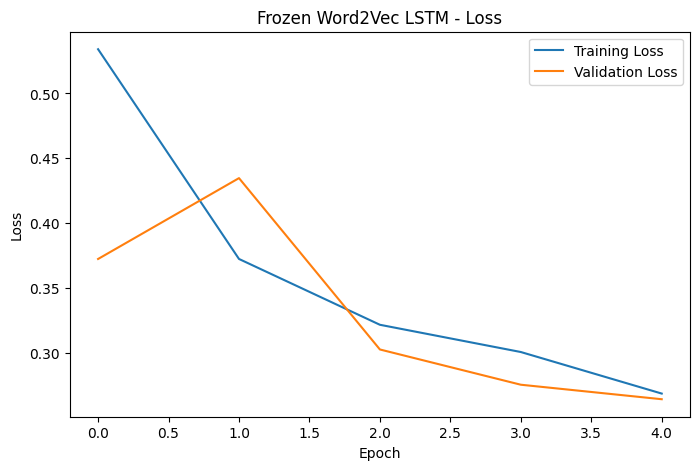

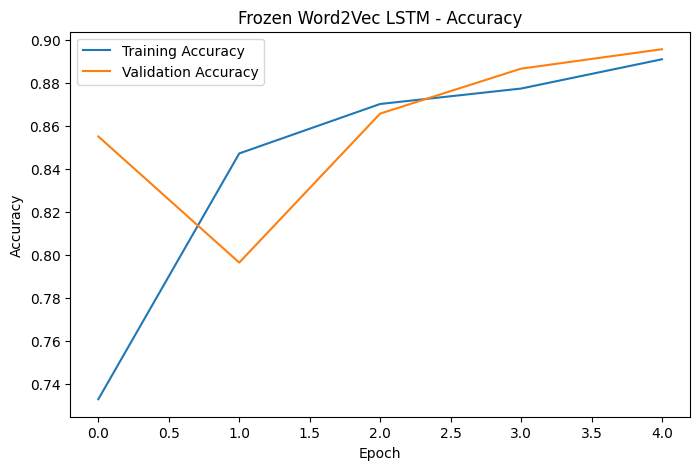

In [240]:
plot_training_history(
    word2vec_frozen_history,
    "Frozen Word2Vec LSTM"
)

In [241]:
del optimizer
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Fine tuned word2Vec LSTM

In [242]:
reset_seed()
word2vec_finetuned_model = LSTMClassifier(
    embedding_matrix=word2vec_embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    freeze_embeddings=False
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    word2vec_finetuned_model.parameters(),
    lr=LEARNING_RATE
)

print("Training Fine-Tuned Word2Vec LSTM...")
print("Device:", device)

word2vec_finetuned_history = train_model(
    model=word2vec_finetuned_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    model_path=MODELS_DIR / "lstm_word2vec_finetuned.pt"
)

Training Fine-Tuned Word2Vec LSTM...
Device: cuda
Epoch 01/5 | Train Loss: 0.3987 | Train Accuracy: 0.8312 | Val Loss: 0.3095 | Val Accuracy: 0.8737
Best model saved.
Epoch 02/5 | Train Loss: 0.2607 | Train Accuracy: 0.9015 | Val Loss: 0.2885 | Val Accuracy: 0.8848
Best model saved.
Epoch 03/5 | Train Loss: 0.1632 | Train Accuracy: 0.9437 | Val Loss: 0.3117 | Val Accuracy: 0.8659
Epoch 04/5 | Train Loss: 0.0937 | Train Accuracy: 0.9702 | Val Loss: 0.4006 | Val Accuracy: 0.8820
Epoch 05/5 | Train Loss: 0.0461 | Train Accuracy: 0.9862 | Val Loss: 0.4826 | Val Accuracy: 0.8745

Training completed in 10.28 minutes.


In [243]:
(
    word2vec_finetuned_metrics,
    word2vec_finetuned_labels,
    word2vec_finetuned_predictions,
    word2vec_finetuned_probabilities
) = evaluate_model(
    word2vec_finetuned_model,
    test_loader,
    device
)

print(word2vec_finetuned_metrics)

print(
    classification_report(
        word2vec_finetuned_labels,
        word2vec_finetuned_predictions,
        target_names=["Negative", "Positive"]
    )
)

print(
    confusion_matrix(
        word2vec_finetuned_labels,
        word2vec_finetuned_predictions
    )
)

{'accuracy': 0.8720616104189347, 'precision': 0.8514753849654858, 'recall': 0.9023311897106109, 'f1': 0.8761659446590954}
              precision    recall  f1-score   support

    Negative       0.90      0.84      0.87     12361
    Positive       0.85      0.90      0.88     12440

    accuracy                           0.87     24801
   macro avg       0.87      0.87      0.87     24801
weighted avg       0.87      0.87      0.87     24801

[[10403  1958]
 [ 1215 11225]]


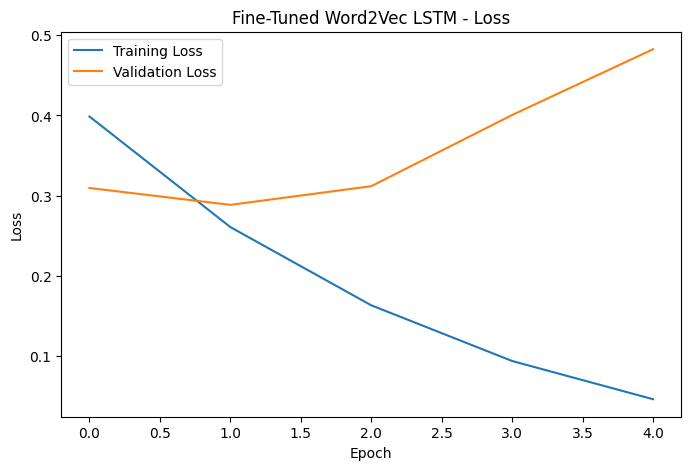

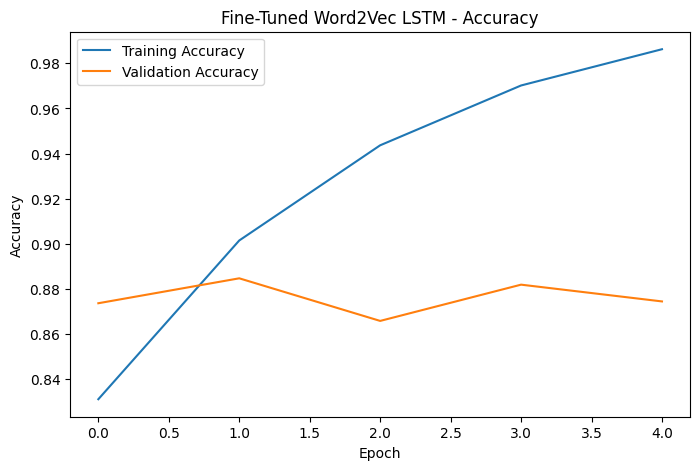

In [244]:
plot_training_history(
    word2vec_finetuned_history,
    "Fine-Tuned Word2Vec LSTM"
)

# Results Comparison

In [245]:
results = [
    {
        "Model": "LSTM",
        "Embedding": "GloVe",
        "Variant": "Frozen",
        **glove_frozen_metrics
    },
    {
        "Model": "LSTM",
        "Embedding": "GloVe",
        "Variant": "Fine-Tuned",
        **glove_finetuned_metrics
    },
    {
        "Model": "LSTM",
        "Embedding": "Word2Vec",
        "Variant": "Frozen",
        **word2vec_frozen_metrics
    },
    {
        "Model": "LSTM",
        "Embedding": "Word2Vec",
        "Variant": "Fine-Tuned",
        **word2vec_finetuned_metrics
    },
     {
        "Model": "LSTM",
        "Embedding": "TF-IDF",
        "Variant": "-",
        **tfidf_metrics
    }
]

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="f1",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Embedding,Variant,accuracy,precision,recall,f1
0,LSTM,Word2Vec,Frozen,0.892988,0.888272,0.899839,0.894018
1,LSTM,TF-IDF,-,0.881698,0.900084,0.859566,0.879359
2,LSTM,Word2Vec,Fine-Tuned,0.872062,0.851475,0.902331,0.876166
3,LSTM,GloVe,Frozen,0.875610,0.896163,0.850563,0.872768
4,LSTM,GloVe,Fine-Tuned,0.866054,0.839616,0.906029,0.871559


In [246]:
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

results_df.to_csv(
    RESULTS_DIR / "lstm_results.csv",
    index=False
)

print("Results saved.")

Results saved.
